<a href="https://colab.research.google.com/github/ShushumnaVazeer/MDS_LAB/blob/main/MDS_Week_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
from google.colab import files

# Load the parquet file
parquet_file_path = '/content/train-00000-of-00001.parquet'
df = pd.read_parquet(parquet_file_path)

# Display the first few rows to confirm it loaded correctly
display(df.head())


,id,city,property_type,area_sqft,bedrooms,bathrooms,floors,floor_number,year_built,age_years,condition,furnishing,parking_spaces,has_garden,has_pool,distance_to_city_center_km,near_school,near_hospital,crime_rate_index,price_bdt
0,1,Chattogram,Apartment,1601,2,1,23,2,2022,4,Good,Unfurnished,1,0,1,2.85,1,1,56.4,19162000
1,2,Dhaka,Duplex,2728,3,3,1,0,2006,20,New,Semi-Furnished,0,1,1,4.56,0,1,52.1,42817000
2,3,Barishal,House,1527,2,2,2,0,1999,27,Fair,Semi-Furnished,0,1,0,9.17,0,1,56.0,7033000
3,4,Khulna,Apartment,1694,1,1,16,1,1999,27,Fair,Fully Furnished,0,0,0,7.30,1,0,48.4,11862000
4,5,Sylhet,Apartment,2153,3,3,24,13,2022,4,Good,Unfurnished,2,0,0,0.56,1,0,35.5,13713000


In [7]:
# Convert to CSV and download
csv_file_path = 'train-00000-of-00001.csv'
df.to_csv(csv_file_path, index=False)

# Download the CSV file
files.download(csv_file_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Normal Probability Plot
We will create a normal probability (Q-Q) plot for the continuous variable `area_sqft` to visually assess if the data follows a normal distribution.

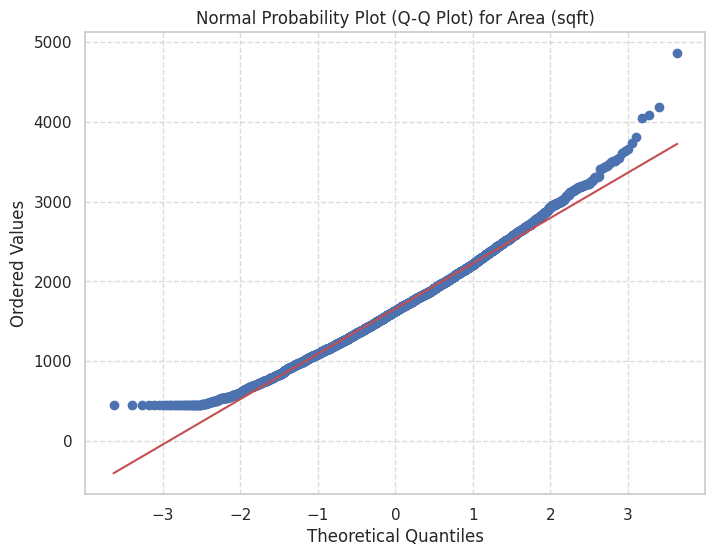

In [8]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Create a Q-Q plot
plt.figure(figsize=(8, 6))
stats.probplot(df['area_sqft'], dist="norm", plot=plt)
plt.title('Normal Probability Plot (Q-Q Plot) for Area (sqft)')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Comprehensive Exploratory Data Analysis Plots
We will now generate multiple visual plots to explore distributions, counts, relationships, and correlations across the different features of the dataset.

/tmp/ipykernel_996/16871744.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='property_type', palette='viridis', order=df['property_type'].value_counts().index, ax=axes[0, 1])
/tmp/ipykernel_996/16871744.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='city', y='area_sqft', palette='Set2', ax=axes[1, 0])
/tmp/ipykernel_996/16871744.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='bedrooms', palette='rocket', ax=axes[1, 1])


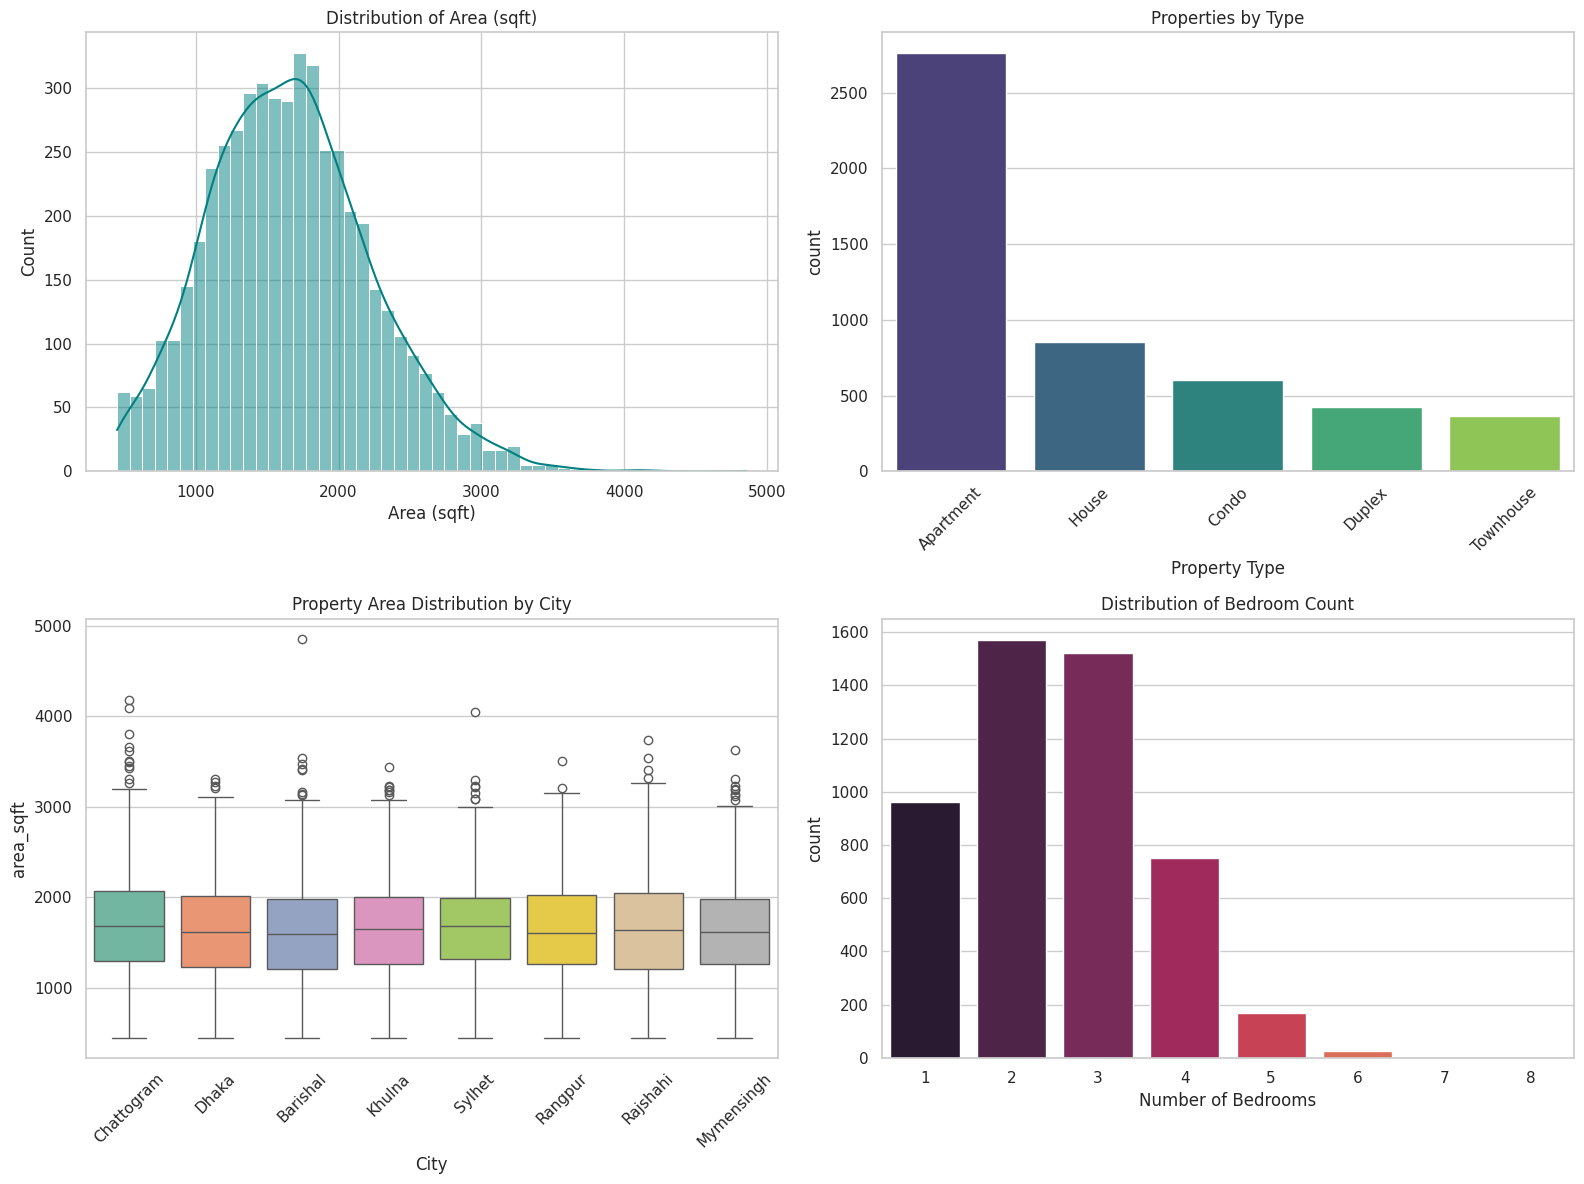

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Set up a multi-plot figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution of Area (sqft)
sns.histplot(df['area_sqft'], kde=True, color='teal', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Area (sqft)')
axes[0, 0].set_xlabel('Area (sqft)')

# 2. Count of Property Types (Warning fixed by setting hue='property_type' and legend=False)
sns.countplot(data=df, x='property_type', hue='property_type', palette='viridis', order=df['property_type'].value_counts().index, legend=False, ax=axes[0, 1])
axes[0, 1].set_title('Properties by Type')
axes[0, 1].set_xlabel('Property Type')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Box plot of Area by City (Warning fixed by setting hue='city' and legend=False)
sns.boxplot(data=df, x='city', y='area_sqft', hue='city', palette='Set2', legend=False, ax=axes[1, 0])
axes[1, 0].set_title('Property Area Distribution by City')
axes[1, 0].set_xlabel('City')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Count of Bedrooms (Warning fixed by setting hue='bedrooms' and legend=False)
sns.countplot(data=df, x='bedrooms', hue='bedrooms', palette='rocket', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Bedroom Count')
axes[1, 1].set_xlabel('Number of Bedrooms')

plt.tight_layout()
plt.show()

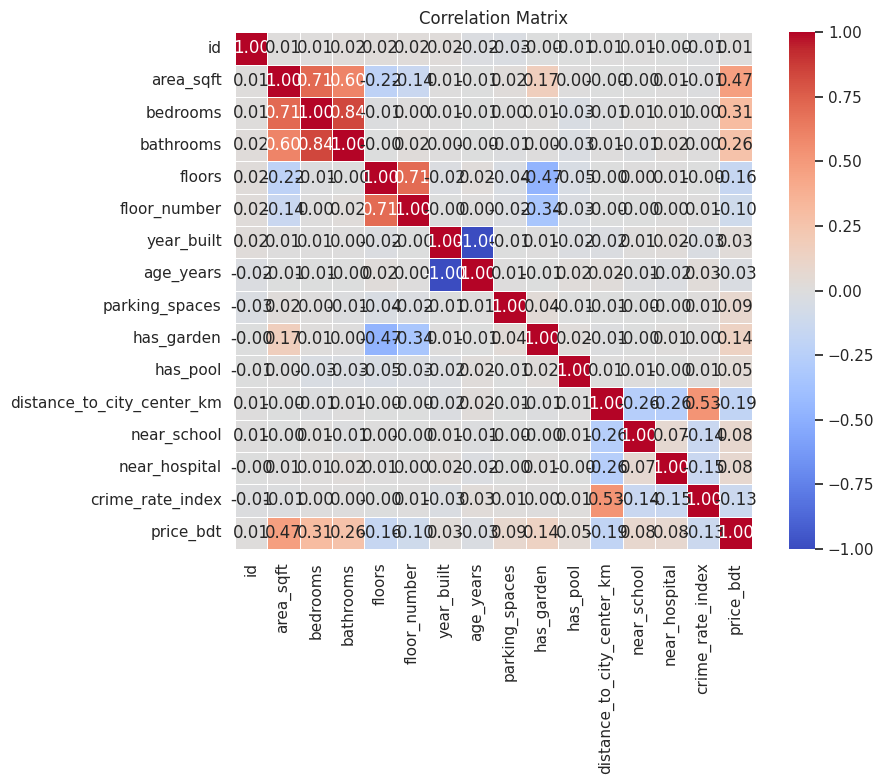

In [10]:
# Correlation heatmap of numerical features
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=['number'])
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### Separate Exploratory Plots

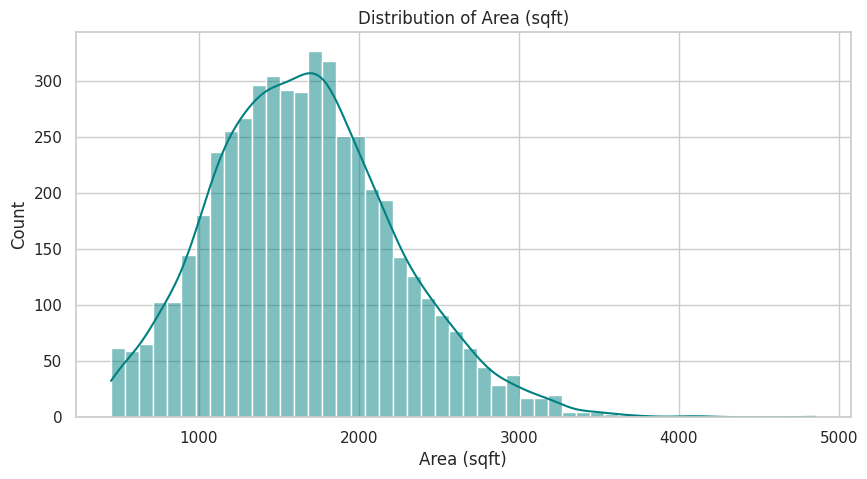

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# 1. Distribution of Area (sqft)
plt.figure(figsize=(10, 5))
sns.histplot(df['area_sqft'], kde=True, color='teal')
plt.title('Distribution of Area (sqft)')
plt.xlabel('Area (sqft)')
plt.ylabel('Count')
plt.show()

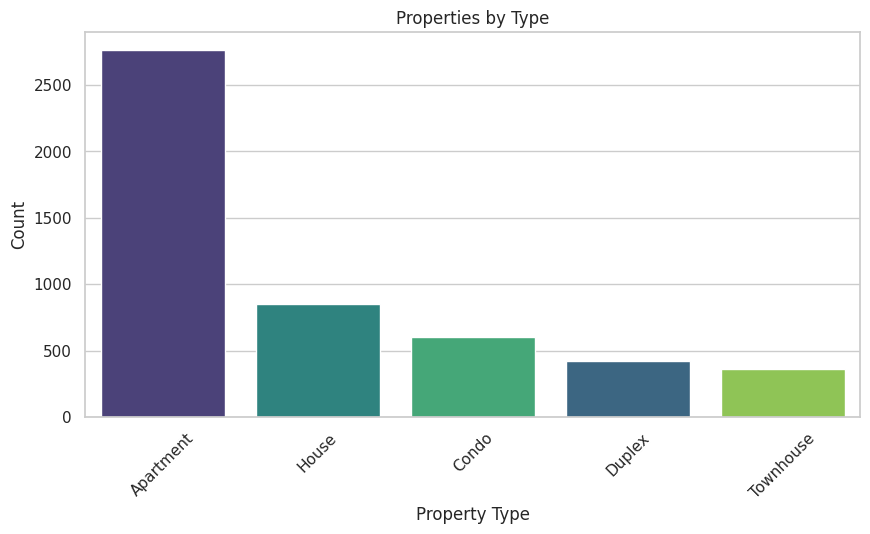

In [12]:
# 2. Count of Property Types
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='property_type', hue='property_type', palette='viridis', order=df['property_type'].value_counts().index, legend=False)
plt.title('Properties by Type')
plt.xlabel('Property Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

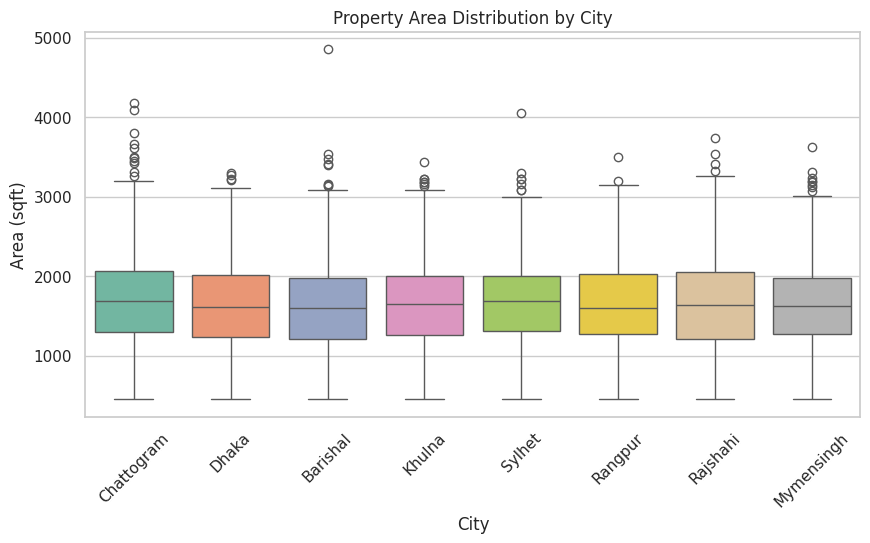

In [13]:
# 3. Box plot of Area by City
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='city', y='area_sqft', hue='city', palette='Set2', legend=False)
plt.title('Property Area Distribution by City')
plt.xlabel('City')
plt.ylabel('Area (sqft)')
plt.xticks(rotation=45)
plt.show()

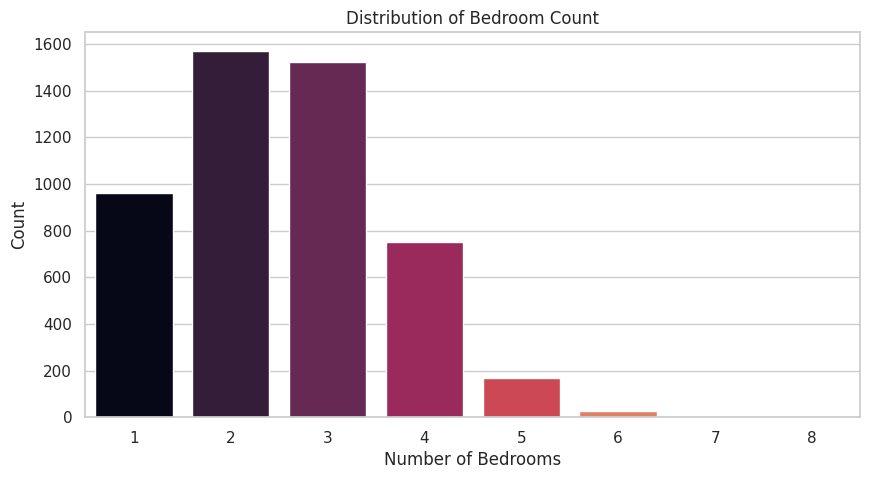

In [14]:
# 4. Count of Bedrooms
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='bedrooms', hue='bedrooms', palette='rocket', legend=False)
plt.title('Distribution of Bedroom Count')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Count')
plt.show()